# Complete Case Analysis (CCA) — Data Science Jobs Dataset

**Complete Case Analysis (CCA)** is the simplest strategy for handling missing data: discard every row that contains at least one missing value, then analyse only the complete rows.

CCA is statistically valid **only when data are Missing Completely At Random (MCAR)** — i.e. the probability of a value being missing is unrelated to any observed or unobserved variable.  
When data are MAR or MNAR, CCA introduces bias; we show both pure CCA and sensible imputation alternatives.

### Notebook outline
1. Load & inspect the raw data  
2. Visualise missing-data patterns  
3. Test for MCAR (Little's test + auxiliary analysis)  
4. Apply CCA (drop rows with any missing value)  
5. Compare distributions before vs after CCA  
6. Alternative: targeted imputation to *replace* missing values  
7. Save cleaned datasets  

---
## 0 · Install / import dependencies

In [1]:
# Uncomment if you need to install
# !pip install missingno scipy scikit-learn --quiet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno

from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

RANDOM_STATE = 42
print('All libraries loaded ✓')

All libraries loaded ✓


---
## 1 · Load & inspect

In [2]:
df_raw = pd.read_csv('data_science_job.csv')

print(f'Shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()

Shape : 19,158 rows × 13 columns


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.9200,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0000,NaN,NaN,36.0000,1.0000
1,29725,city_40,0.7760,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0000,50-99,Pvt Ltd,47.0000,0.0000
2,11561,city_21,0.6240,NaN,No relevent experience,Full time course,Graduate,STEM,5.0000,NaN,NaN,83.0000,0.0000
3,33241,city_115,0.7890,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0000,NaN,Pvt Ltd,52.0000,1.0000
4,666,city_162,0.7670,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0000,50-99,Funded Startup,8.0000,0.0000


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  str    
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  str    
 4   relevent_experience     19158 non-null  str    
 5   enrolled_university     18772 non-null  str    
 6   education_level         18698 non-null  str    
 7   major_discipline        16345 non-null  str    
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  str    
 10  company_type            13018 non-null  str    
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), str(8)
memory usage: 1.9 MB


In [4]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
enrollee_id,19158.0000,NaN,NaN,NaN,16875.3582,9616.2926,1.0000,8554.2500,16982.5000,25169.7500,33380.0000
city,19158,123,city_103,4355,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_development_index,18679.0000,NaN,NaN,NaN,0.8290,0.1233,0.4480,0.7400,0.9030,0.9200,0.9490
gender,14650,3,Male,13221,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relevent_experience,19158,2,Has relevent experience,13792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
enrolled_university,18772,3,no_enrollment,13817,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,18698,5,Graduate,11598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
major_discipline,16345,6,STEM,14492,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience,19093.0000,NaN,NaN,NaN,9.9280,6.5053,0.0000,4.0000,9.0000,16.0000,20.0000
company_size,13220,8,50-99,3083,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2 · Visualise missing-data patterns

In [5]:
# ── 2a  Missing count & percentage summary ──────────────────────────────────
missing = (
    df_raw.isnull()
          .sum()
          .to_frame('n_missing')
          .assign(pct_missing=lambda x: x['n_missing'] / len(df_raw) * 100)
          .sort_values('pct_missing', ascending=False)
)
missing = missing[missing['n_missing'] > 0]
print(f"{len(missing)} columns have missing values\n")
display(missing.style.background_gradient(cmap='Reds', subset=['pct_missing']).format({'pct_missing': '{:.2f}%'}))

9 columns have missing values



,n_missing,pct_missing
company_type,6140,32.05%
company_size,5938,30.99%
gender,4508,23.53%
major_discipline,2813,14.68%
training_hours,766,4.00%
city_development_index,479,2.50%
education_level,460,2.40%
enrolled_university,386,2.01%
experience,65,0.34%


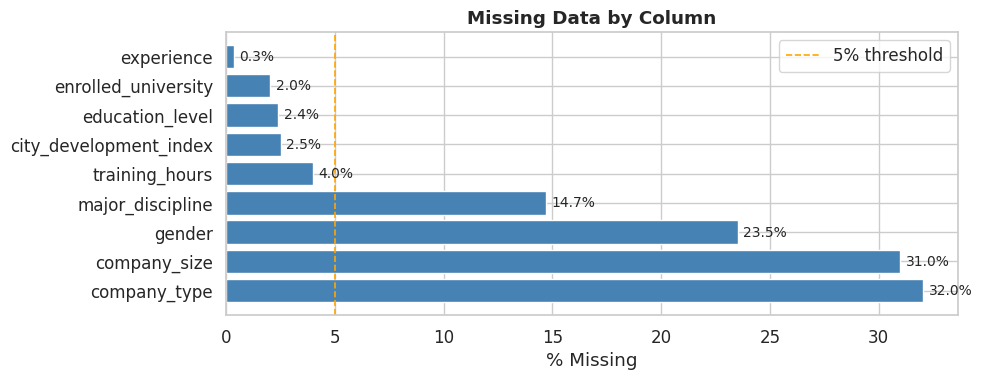

In [6]:
# ── 2b  Bar chart of missingness ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing.index, missing['pct_missing'], color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
ax.set_xlabel('% Missing')
ax.set_title('Missing Data by Column', fontweight='bold')
ax.axvline(5, color='orange', linestyle='--', linewidth=1.2, label='5% threshold')
ax.legend()
plt.tight_layout()
plt.show()

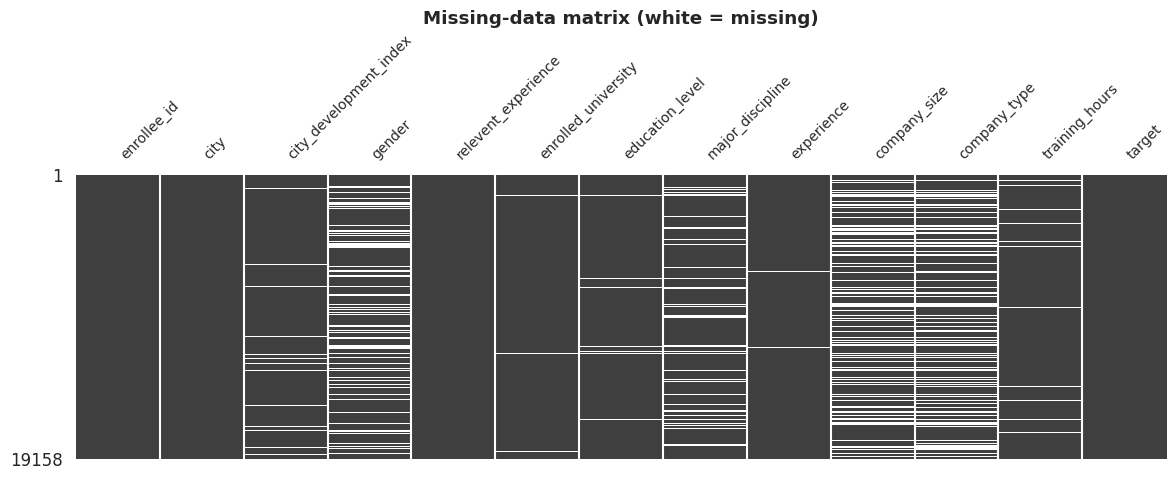

In [7]:
# ── 2c  missingno matrix (pattern of co-occurring nulls) ────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
msno.matrix(df_raw, ax=ax, sparkline=False, fontsize=10)
ax.set_title('Missing-data matrix (white = missing)', fontweight='bold')
plt.tight_layout()
plt.show()

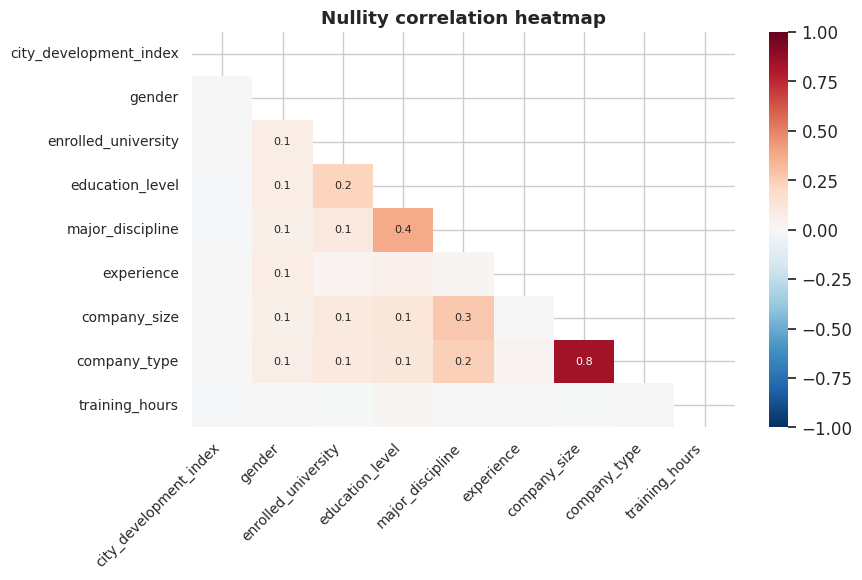


Interpretation:
  +1  → the two columns are always missing together (same rows)
   0  → missingness is independent
  −1  → when one is missing the other is always present

High correlations between missing indicators suggest the data are
NOT missing completely at random (MCAR) — they may be MAR or MNAR.



In [8]:
# ── 2d  missingno heatmap (correlation between missing indicators) ───────────
fig, ax = plt.subplots(figsize=(9, 6))
msno.heatmap(df_raw, ax=ax, fontsize=10, cmap='RdBu_r')
ax.set_title('Nullity correlation heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Interpretation:
  +1  → the two columns are always missing together (same rows)
   0  → missingness is independent
  −1  → when one is missing the other is always present

High correlations between missing indicators suggest the data are
NOT missing completely at random (MCAR) — they may be MAR or MNAR.
""")

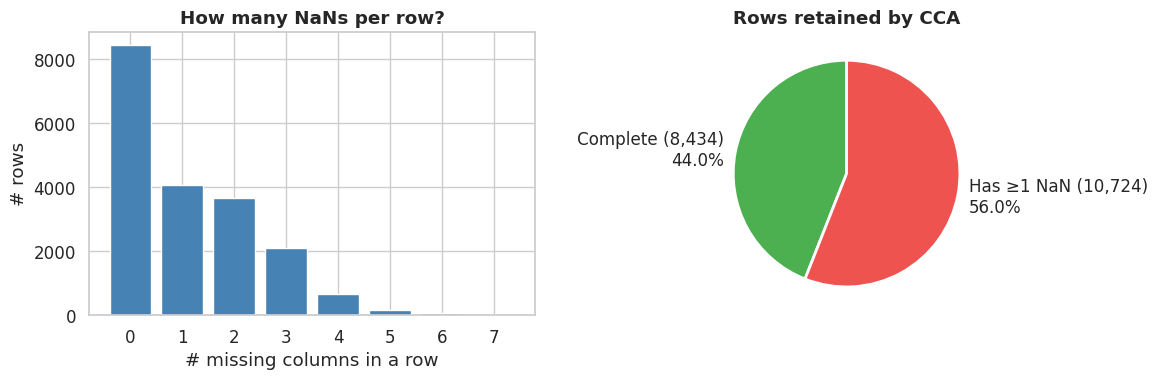

In [9]:
# ── 2e  Row-level: how many missing values per row? ─────────────────────────
row_miss = df_raw.isnull().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution
ax = axes[0]
counts = row_miss.value_counts().sort_index()
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('# missing columns in a row')
ax.set_ylabel('# rows')
ax.set_title('How many NaNs per row?', fontweight='bold')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Cumulative proportion complete after CCA
ax2 = axes[1]
n_complete = (row_miss == 0).sum()
sizes = [n_complete, len(df_raw) - n_complete]
labels = [f'Complete ({n_complete:,})\n{n_complete/len(df_raw)*100:.1f}%',
          f'Has ≥1 NaN ({len(df_raw)-n_complete:,})\n{(len(df_raw)-n_complete)/len(df_raw)*100:.1f}%']
ax2.pie(sizes, labels=labels, colors=['#4CAF50', '#EF5350'],
        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Rows retained by CCA', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3 · Test for MCAR

We use two complementary approaches:
- **Little's MCAR test** (chi-squared): H₀ = data are MCAR. A *significant* p-value rejects MCAR.
- **Auxiliary t-tests / chi-squared tests**: compare observed values across missing / non-missing groups for each affected column.

In [10]:
def little_mcar_test(df: pd.DataFrame) -> dict:
    """
    Little's MCAR test implemented from scratch.
    Works on numeric columns only (NaN-indicator pattern + column means).
    Returns a dict with test statistic, p-value, and degrees of freedom.
    Reference: Little (1988), JASA 83(404), 1198-1202.
    """
    # Use only numeric columns that have at least one missing value
    num_cols = df.select_dtypes(include='number').columns.tolist()
    df_num = df[num_cols].copy()
    missing_num = df_num.columns[df_num.isnull().any()].tolist()

    if len(missing_num) < 2:
        return {'error': 'Need ≥2 numeric columns with missing values.'}

    df_num = df_num[missing_num]

    # Create a missing-indicator pattern per row
    indicator = df_num.isnull().astype(int)
    patterns = indicator.apply(lambda r: tuple(r), axis=1)
    pattern_groups = df_num.groupby(patterns)

    # Grand means (ignoring NaN)
    grand_means = df_num.mean()
    grand_cov   = df_num.cov()

    d2_total = 0.0
    df_total = 0

    for pattern, group in pattern_groups:
        observed_cols = [c for c, miss in zip(df_num.columns, pattern) if miss == 0]
        if len(observed_cols) == 0:
            continue

        n_k    = len(group)
        mu_k   = group[observed_cols].mean()
        mu_obs = grand_means[observed_cols]
        diff   = (mu_k - mu_obs).values.reshape(-1, 1)

        cov_sub = grand_cov.loc[observed_cols, observed_cols].values
        try:
            cov_inv = np.linalg.pinv(cov_sub)
            d2_total += n_k * (diff.T @ cov_inv @ diff).item()
            df_total += len(observed_cols)
        except np.linalg.LinAlgError:
            continue

    # Degrees of freedom = sum of observed vars per pattern − total vars
    dof = max(df_total - len(df_num.columns), 1)
    p   = 1 - stats.chi2.cdf(d2_total, dof)
    return {'chi2': d2_total, 'df': dof, 'p_value': p,
            'mcar': p > 0.05, 'columns_tested': missing_num}


result = little_mcar_test(df_raw)
print('=== Little\'s MCAR Test ===')
if 'error' not in result:
    print(f"  χ² statistic : {result['chi2']:.4f}")
    print(f"  Degrees of freedom: {result['df']}")
    print(f"  p-value      : {result['p_value']:.6f}")
    print(f"  MCAR likely? : {'✓ YES (fail to reject H₀)' if result['mcar'] else '✗ NO (reject H₀)'}")
    print(f"  Columns used : {result['columns_tested']}")
else:
    print(result['error'])

=== Little's MCAR Test ===
  χ² statistic : 21.9275
  Degrees of freedom: 9
  p-value      : 0.009112
  MCAR likely? : ✗ NO (reject H₀)
  Columns used : ['city_development_index', 'experience', 'training_hours']


In [11]:
# ── Auxiliary analysis: do values of observed cols differ by missingness? ────
# For each column with NaN, compare `training_hours` (numeric) and `target`
# between rows where that column is missing vs present.

print("=== Auxiliary MCAR check (Mann-Whitney U test on `training_hours`) ===")
print("H₀ per column: distribution of training_hours is the same")
print("whether that column is missing or not.\n")

cols_with_missing = [c for c in df_raw.columns if df_raw[c].isnull().any()]
results_aux = []

for col in cols_with_missing:
    mask_miss    = df_raw[col].isnull()
    group_miss   = df_raw.loc[mask_miss,   'training_hours'].dropna()
    group_obs    = df_raw.loc[~mask_miss,  'training_hours'].dropna()

    if len(group_miss) > 5 and len(group_obs) > 5:
        stat, p = stats.mannwhitneyu(group_miss, group_obs, alternative='two-sided')
        results_aux.append({
            'column': col,
            'n_missing': mask_miss.sum(),
            'mean_training_when_missing': group_miss.mean(),
            'mean_training_when_present': group_obs.mean(),
            'p_value': p,
            'significant (p<0.05)': p < 0.05
        })

aux_df = pd.DataFrame(results_aux)
display(
    aux_df.style
          .map(lambda v: 'background-color:#ffcccc' if v is True else '',
                    subset=['significant (p<0.05)'])
          .format({'p_value': '{:.4f}',
                   'mean_training_when_missing': '{:.2f}',
                   'mean_training_when_present': '{:.2f}'})
)
print("\n⚠ Columns with significant p-values are likely NOT MCAR.")

=== Auxiliary MCAR check (Mann-Whitney U test on `training_hours`) ===
H₀ per column: distribution of training_hours is the same
whether that column is missing or not.



,column,n_missing,mean_training_when_missing,mean_training_when_present,p_value,significant (p<0.05)
0,city_development_index,479,64.84,65.19,0.6258,False
1,gender,4508,65.37,65.13,0.8383,False
2,enrolled_university,386,67.27,65.14,0.4001,False
3,education_level,460,67.49,65.13,0.2480,False
4,major_discipline,2813,66.44,64.97,0.1092,False
5,experience,65,71.10,65.17,0.3177,False
6,company_size,5938,64.70,65.41,0.7885,False
7,company_type,6140,64.93,65.31,0.5883,False



⚠ Columns with significant p-values are likely NOT MCAR.


---
## 4 · Complete Case Analysis — remove all rows with any missing value

CCA is appropriate here for columns with low missingness (< 5 %).  
For columns with high missingness (e.g. `company_size` ~31 %, `company_type` ~32 %) CCA discards too many rows and likely introduces bias — we address those in Section 6.

In [12]:
# ── 4a  Full CCA (drop any row with at least one NaN) ───────────────────────
df_cca_full = df_raw.dropna()

print('=== Full CCA ===')
print(f'  Original rows : {len(df_raw):>8,}')
print(f'  Rows retained : {len(df_cca_full):>8,}  ({len(df_cca_full)/len(df_raw)*100:.1f}%)')
print(f'  Rows dropped  : {len(df_raw)-len(df_cca_full):>8,}  ({(len(df_raw)-len(df_cca_full))/len(df_raw)*100:.1f}%)')
print(f'\n  Any NaN remaining? {df_cca_full.isnull().any().any()}')

=== Full CCA ===
  Original rows :   19,158
  Rows retained :    8,434  (44.0%)
  Rows dropped  :   10,724  (56.0%)

  Any NaN remaining? False


In [13]:
# ── 4b  Selective CCA — only drop rows missing in low-miss columns ────────────
# Strategy: keep company_size and company_type (high-miss) for imputation
# and apply CCA only to the columns where <10% is missing.

low_miss_threshold = 10.0  # percent — tune as needed
low_miss_cols = missing[missing['pct_missing'] <= low_miss_threshold].index.tolist()

print(f'Columns with ≤ {low_miss_threshold}% missing (CCA applied to these):')
print(low_miss_cols)

df_cca_selective = df_raw.dropna(subset=low_miss_cols)

print(f'\n=== Selective CCA (subset={low_miss_cols}) ===')
print(f'  Original rows : {len(df_raw):>8,}')
print(f'  Rows retained : {len(df_cca_selective):>8,}  ({len(df_cca_selective)/len(df_raw)*100:.1f}%)')
print(f'  Rows dropped  : {len(df_raw)-len(df_cca_selective):>8,}  ({(len(df_raw)-len(df_cca_selective))/len(df_raw)*100:.1f}%)')

Columns with ≤ 10.0% missing (CCA applied to these):
['training_hours', 'city_development_index', 'education_level', 'enrolled_university', 'experience']

=== Selective CCA (subset=['training_hours', 'city_development_index', 'education_level', 'enrolled_university', 'experience']) ===
  Original rows :   19,158
  Rows retained :   17,182  (89.7%)
  Rows dropped  :    1,976  (10.3%)


---
## 5 · Compare distributions before vs after CCA

A key diagnostic: if CCA changes the distribution of a variable substantially, the data are **not MCAR** and CCA may bias downstream models.

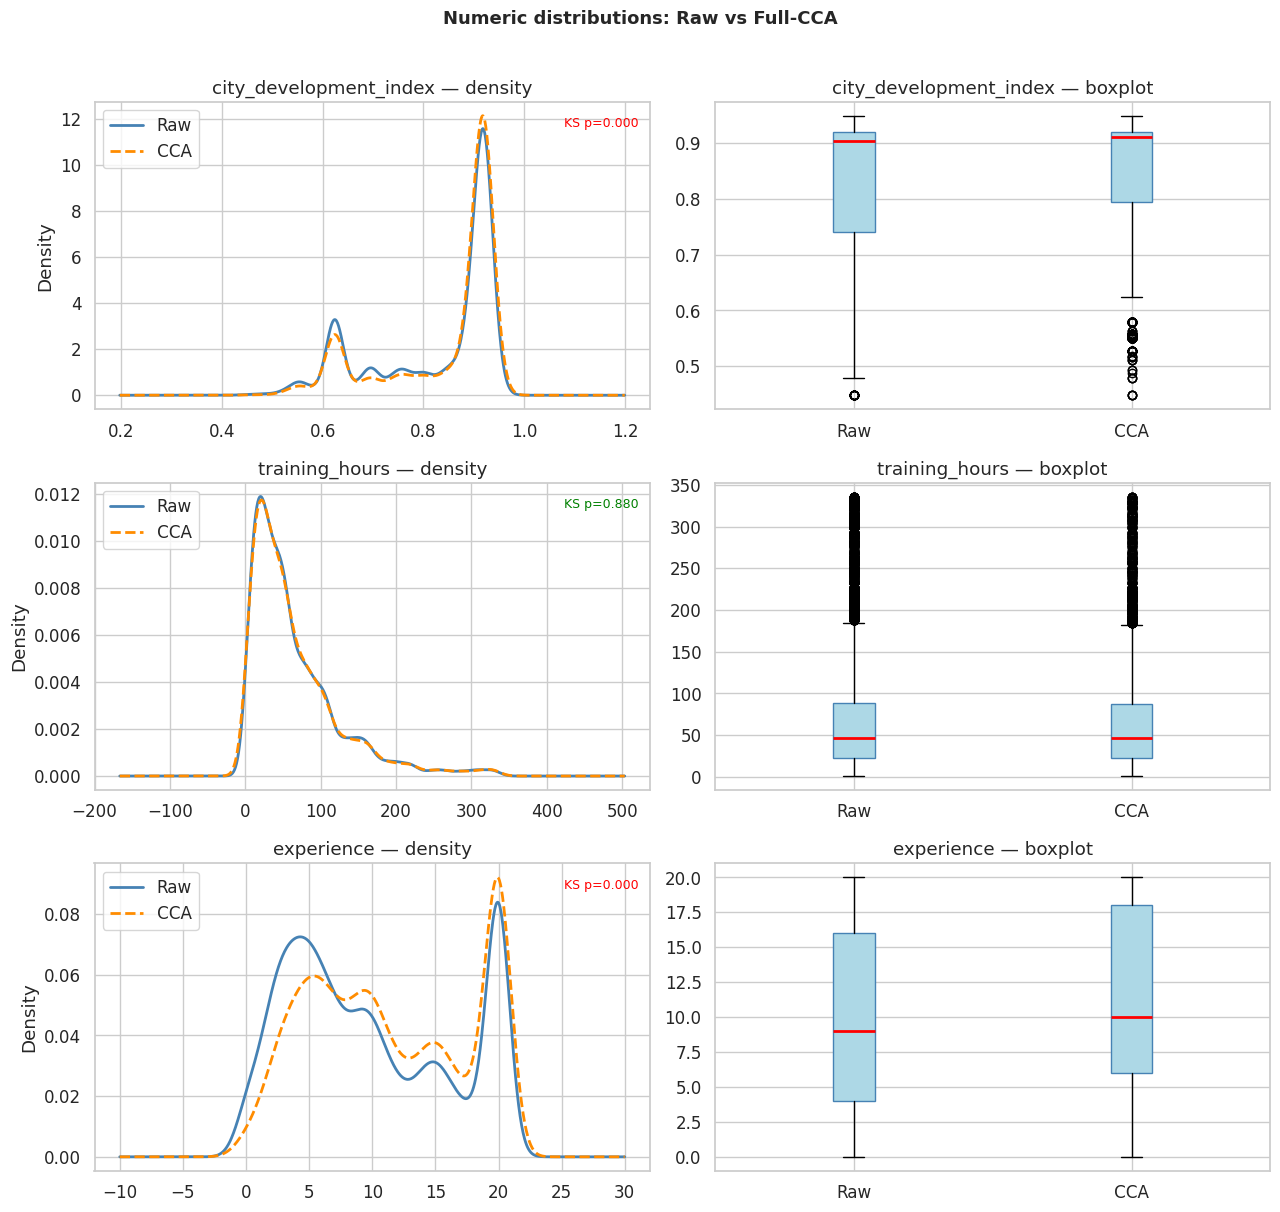

KS p > 0.05  →  distributions are statistically similar after CCA (good).
KS p ≤ 0.05  →  CCA has shifted the distribution — potential bias.


In [14]:
# ── 5a  Numeric columns ──────────────────────────────────────────────────────
num_cols = ['city_development_index', 'training_hours', 'experience']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(13, 4 * len(num_cols)))
fig.suptitle('Numeric distributions: Raw vs Full-CCA', fontweight='bold', fontsize=13, y=1.01)

for i, col in enumerate(num_cols):
    raw_vals = df_raw[col].dropna()
    cca_vals = df_cca_full[col]

    # KDE overlay
    ax = axes[i, 0]
    raw_vals.plot.kde(ax=ax, label='Raw', linewidth=2, color='steelblue')
    cca_vals.plot.kde(ax=ax, label='CCA',  linewidth=2, color='darkorange', linestyle='--')
    ax.set_title(f'{col} — density')
    ax.legend()

    # Boxplot
    ax2 = axes[i, 1]
    ax2.boxplot([raw_vals, cca_vals], labels=['Raw', 'CCA'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
    ax2.set_title(f'{col} — boxplot')

    # KS test
    ks_stat, ks_p = stats.ks_2samp(raw_vals, cca_vals)
    ax.text(0.98, 0.95, f'KS p={ks_p:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            color='green' if ks_p > 0.05 else 'red')

plt.tight_layout()
plt.show()

print("KS p > 0.05  →  distributions are statistically similar after CCA (good).")
print("KS p ≤ 0.05  →  CCA has shifted the distribution — potential bias.")

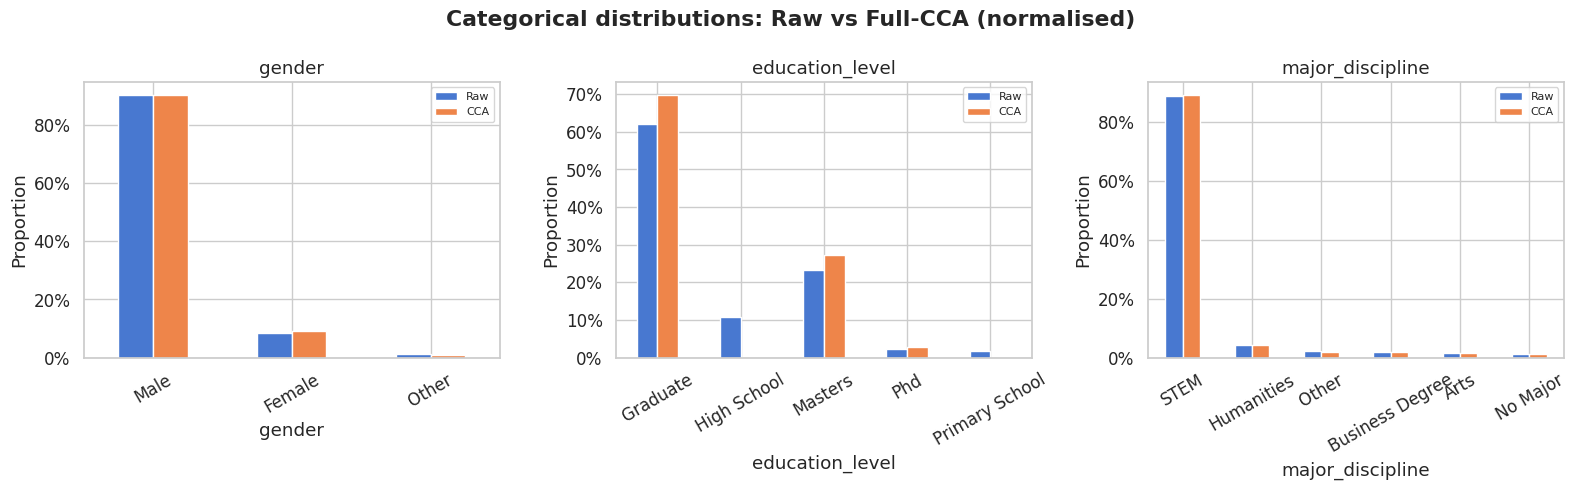

In [15]:
# ── 5b  Categorical columns ───────────────────────────────────────────────────
cat_cols = ['gender', 'education_level', 'major_discipline']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(16, 5))
fig.suptitle('Categorical distributions: Raw vs Full-CCA (normalised)', fontweight='bold')

for ax, col in zip(axes, cat_cols):
    raw_norm = df_raw[col].value_counts(normalize=True)
    cca_norm = df_cca_full[col].value_counts(normalize=True)
    comp = pd.DataFrame({'Raw': raw_norm, 'CCA': cca_norm}).fillna(0)
    comp.plot.bar(ax=ax, rot=30, edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Proportion')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [16]:
# ── 5c  Target distribution check ────────────────────────────────────────────
print('Target distribution (proportion looking for a job change):')
print(pd.DataFrame({
    'Raw': df_raw['target'].value_counts(normalize=True),
    'Full CCA': df_cca_full['target'].value_counts(normalize=True),
    'Selective CCA': df_cca_selective['target'].value_counts(normalize=True)
}).round(4))

Target distribution (proportion looking for a job change):
          Raw  Full CCA  Selective CCA
target                                
0.0000 0.7507    0.8347         0.7518
1.0000 0.2493    0.1653         0.2482


---
## 6 · Alternative: Imputation to *replace* missing values

When CCA discards too many rows or distorts distributions, imputation is preferred:

| Column type | Strategy | Rationale |
|---|---|---|
| Low-cardinality categorical | Mode (most-frequent) | Simple, interpretable |
| Numeric | Median | Robust to outliers |
| Numeric (when MCAR) | KNN Imputer | Uses similar rows |

We build two pipelines and compare.

In [17]:
# ── 6a  Identify column roles ─────────────────────────────────────────────────
df = df_raw.copy()

cat_missing   = [c for c in df.select_dtypes('object').columns if df[c].isnull().any()]
num_missing   = [c for c in df.select_dtypes('number').columns  if df[c].isnull().any()]

print('Categorical columns needing imputation:', cat_missing)
print('Numeric columns needing imputation    :', num_missing)

Categorical columns needing imputation: ['gender', 'enrolled_university', 'education_level', 'major_discipline', 'company_size', 'company_type']
Numeric columns needing imputation    : ['city_development_index', 'experience', 'training_hours']


In [18]:
# ── 6b  Simple imputation (mode / median) ────────────────────────────────────
df_simple = df_raw.copy()

# Categorical → mode
mode_imp = SimpleImputer(strategy='most_frequent')
df_simple[cat_missing] = mode_imp.fit_transform(df_simple[cat_missing])

# Numeric → median
med_imp = SimpleImputer(strategy='median')
df_simple[num_missing] = med_imp.fit_transform(df_simple[num_missing])

assert df_simple.isnull().sum().sum() == 0, "Still has NaN!"
print('Simple imputation complete.')
print(f'Rows: {len(df_simple):,} (all original rows preserved)')
df_simple.head()

Simple imputation complete.
Rows: 19,158 (all original rows preserved)


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.9200,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0000,50-99,Pvt Ltd,36.0000,1.0000
1,29725,city_40,0.7760,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0000,50-99,Pvt Ltd,47.0000,0.0000
2,11561,city_21,0.6240,Male,No relevent experience,Full time course,Graduate,STEM,5.0000,50-99,Pvt Ltd,83.0000,0.0000
3,33241,city_115,0.7890,Male,No relevent experience,no_enrollment,Graduate,Business Degree,0.0000,50-99,Pvt Ltd,52.0000,1.0000
4,666,city_162,0.7670,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0000,50-99,Funded Startup,8.0000,0.0000


In [19]:
# ── 6c  KNN imputation (numeric only) ────────────────────────────────────────
# KNN works on numeric values; we encode categoricals for distance computation
df_knn = df_raw.copy()

# Encode all object cols to integers
le = LabelEncoder()
encoded_cats = {}
for col in df_knn.select_dtypes('object').columns:
    non_null = df_knn[col].dropna()
    le.fit(non_null)
    encoded_cats[col] = le
    # Map known labels; leave NaN as NaN so KNN can impute them
    df_knn[col] = df_knn[col].map(lambda x: le.transform([x])[0]
                                             if pd.notna(x) and x in le.classes_
                                             else np.nan)

knn_imp = KNNImputer(n_neighbors=5, weights='distance')
df_knn_arr = knn_imp.fit_transform(df_knn)
df_knn = pd.DataFrame(df_knn_arr, columns=df_knn.columns)

# Round encoded categoricals back to integer, then decode
for col, enc in encoded_cats.items():
    df_knn[col] = df_knn[col].round().astype(int).clip(0, len(enc.classes_)-1)
    df_knn[col] = enc.inverse_transform(df_knn[col])

assert df_knn.isnull().sum().sum() == 0, "Still has NaN!"
print('KNN imputation complete.')
print(f'Rows: {len(df_knn):,} (all original rows preserved)')
df_knn.head()

KNN imputation complete.
Rows: 19,158 (all original rows preserved)


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949.0000,Pvt Ltd,0.9200,Funded Startup,Early Stage Startup,NGO,Early Stage Startup,Pvt Ltd,20.0000,Other,Public Sector,36.0000,1.0000
1,29725.0000,Pvt Ltd,0.7760,Funded Startup,Funded Startup,NGO,Early Stage Startup,Pvt Ltd,15.0000,Public Sector,Pvt Ltd,47.0000,0.0000
2,11561.0000,Pvt Ltd,0.6240,Funded Startup,Funded Startup,Early Stage Startup,Early Stage Startup,Pvt Ltd,5.0000,Public Sector,Other,83.0000,0.0000
3,33241.0000,Pvt Ltd,0.7890,Funded Startup,Funded Startup,Funded Startup,Early Stage Startup,Funded Startup,0.0000,Other,Pvt Ltd,52.0000,1.0000
4,666.0000,Pvt Ltd,0.7670,Funded Startup,Early Stage Startup,NGO,NGO,Pvt Ltd,20.0000,Public Sector,Funded Startup,8.0000,0.0000


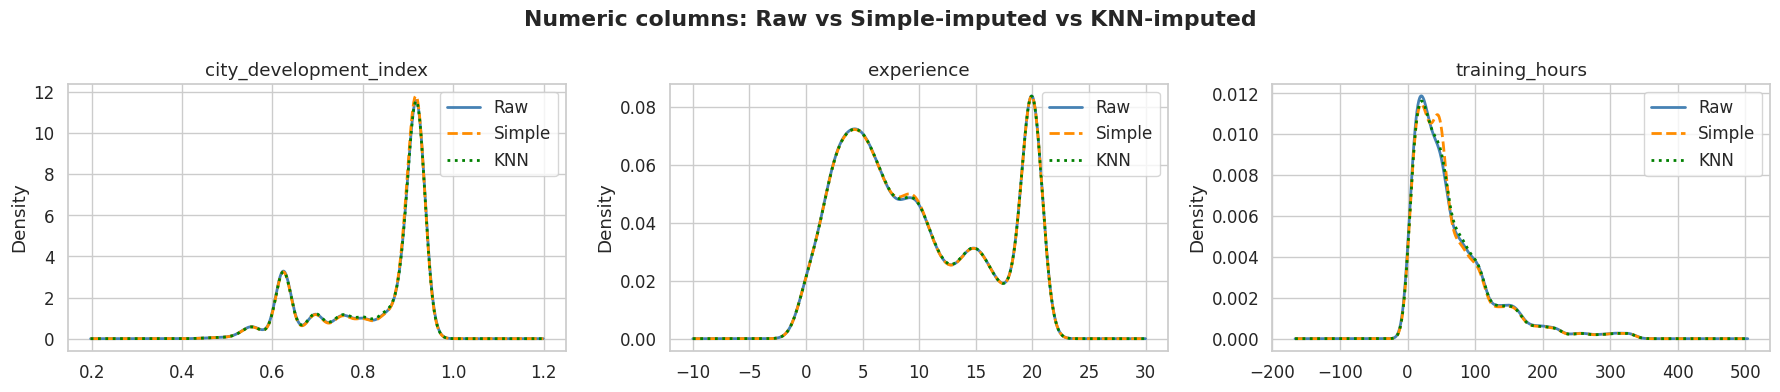

In [20]:
# ── 6d  Compare imputed vs raw distributions ─────────────────────────────────
fig, axes = plt.subplots(1, len(num_missing), figsize=(6 * len(num_missing), 4))
if len(num_missing) == 1:
    axes = [axes]

fig.suptitle('Numeric columns: Raw vs Simple-imputed vs KNN-imputed', fontweight='bold')

for ax, col in zip(axes, num_missing):
    df_raw[col].dropna().plot.kde(ax=ax, label='Raw',    linewidth=2, color='steelblue')
    df_simple[col].plot.kde     (ax=ax, label='Simple',  linewidth=2, color='darkorange', linestyle='--')
    df_knn[col].plot.kde        (ax=ax, label='KNN',     linewidth=2, color='green',      linestyle=':')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

In [21]:
# ── 6e  Summary comparison table ─────────────────────────────────────────────
summary = pd.DataFrame({
    'Method': ['Original (raw)', 'Full CCA', 'Selective CCA',
               'Simple Imputation (mode/median)', 'KNN Imputation'],
    'Rows retained': [
        len(df_raw),
        len(df_cca_full),
        len(df_cca_selective),
        len(df_simple),
        len(df_knn)
    ],
    '% retained': [
        100,
        round(len(df_cca_full)/len(df_raw)*100, 1),
        round(len(df_cca_selective)/len(df_raw)*100, 1),
        100,
        100
    ],
    'Remaining NaNs': [
        df_raw.isnull().sum().sum(),
        0, 0, 0, 0
    ],
    'Assumptions': [
        '—',
        'MCAR required',
        'MCAR in selected cols',
        'MAR OK; may shrink variance',
        'MAR OK; uses local structure'
    ]
})

display(summary.style.hide(axis='index')
                      .set_caption('Comparison of missing-data strategies')
                      .background_gradient(cmap='Greens', subset=['% retained']))

Method,Rows retained,% retained,Remaining NaNs,Assumptions
Original (raw),19158,100.000000,21555,—
Full CCA,8434,44.000000,0,MCAR required
Selective CCA,17182,89.700000,0,MCAR in selected cols
Simple Imputation (mode/median),19158,100.000000,0,MAR OK; may shrink variance
KNN Imputation,19158,100.000000,0,MAR OK; uses local structure


---
## 7 · Save cleaned datasets

In [22]:
df_cca_full.to_csv('data_science_job_cca_full.csv',       index=False)
df_cca_selective.to_csv('data_science_job_cca_selective.csv', index=False)
df_simple.to_csv('data_science_job_simple_imputed.csv',   index=False)
df_knn.to_csv('data_science_job_knn_imputed.csv',         index=False)

print('Saved:')
print('  data_science_job_cca_full.csv        — rows with any NaN removed')
print('  data_science_job_cca_selective.csv   — rows missing in low-miss cols removed')
print('  data_science_job_simple_imputed.csv  — mode/median imputed')
print('  data_science_job_knn_imputed.csv     — KNN imputed')

Saved:
  data_science_job_cca_full.csv        — rows with any NaN removed
  data_science_job_cca_selective.csv   — rows missing in low-miss cols removed
  data_science_job_simple_imputed.csv  — mode/median imputed
  data_science_job_knn_imputed.csv     — KNN imputed


---
## Summary & recommendations

| Finding | Implication |
|---|---|
| `company_size` & `company_type` each ~31–32% missing, **correlated** with other indicators | Almost certainly **not MCAR** — CCA on these columns is inadvisable |
| `gender` 23% missing | Likely MAR (e.g. unreported by smaller companies) — imputation preferable |
| `city_development_index`, `training_hours`, `education_level` < 5% missing | CCA is defensible if KS test shows stable distributions |

**Recommended pipeline for modelling:**
1. Apply **Selective CCA** (drop rows missing in < 5 % columns).
2. Apply **mode imputation** to remaining categorical NaNs (`gender`, `major_discipline`, `company_type`, `company_size`).
3. Apply **median imputation** to any remaining numeric NaNs.
4. Verify KS test p > 0.05 on key numeric columns post-imputation.
5. For high-stakes models, consider **multiple imputation** (e.g. `IterativeImputer`) to propagate uncertainty.